In [ ]:
# importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
# connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the cleaned dataset from Google Drive
df=pd.read_csv('/content/drive/MyDrive/cleaned_dataset.csv')

In [ ]:
# Display the first few rows of the dataset
df.head()

,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [ ]:
X = df.drop(["Time_taken_min", "Average_Speed_kmph"], axis=1)
y = df["Time_taken_min"]

In [ ]:
# Split the data into training and testing parts
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Seperation of numerical and categorical Features
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals']
Categorical: ['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']


In [ ]:
# Define nominal and ordinal feature groups for encoding
nominal_col=['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type']
ordinal_col=['Restaurant_Load','Traffic_Level', 'Delivery_Priority']

In [ ]:
# Pipeline for numerical features (imputation and scaling)
num_pipeline=Pipeline([
        ('imputer',SimpleImputer(strategy='mean')),
        ('scalar',StandardScaler())
    ])

In [ ]:
# Pipeline for numerical features (imputation and scaling)
nominal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
# Pipeline for ordinal categorical features (imputation and ordinal encoding)
ordinal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OrdinalEncoder(
        categories=[
            ["Low", "Medium", "High"],
            ["Low", "Moderate", "High", "Severe"],
            ["Normal", "Priority", "VIP"]
        ])
    )
])

In [ ]:
# Combine numerical, nominal, and ordinal feature pipelines
preprocessor=ColumnTransformer(
    transformers=(
        ('num',num_pipeline,num_cols),
        ('nominal',nominal_pipeline,nominal_col),
        ('ordinal',ordinal_pipeline,ordinal_col)
    ),remainder='drop'
)

In [ ]:
model=ExtraTreesRegressor()
extratree=Pipeline(
    [('preprocessor',preprocessor),
     ('model',model)]
)
extratree.fit(X_train,y_train)
y_pred=extratree.predict(X_test)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2score=r2_score(y_test,y_pred)

print(f"MAE  : {mae}")
print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"R²   : {r2score}")

MAE  : 2.8194739999999996
MSE  : 13.511008399999998
RMSE : 3.6757323624007228
R²   : 0.9893633648330828


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30, 50],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=extratree,
    param_distributions=param_dist,
    n_iter=10,               # Number of parameter settings sampled
    cv=3,                    # 3-fold cross-validation
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit randomized search on training data
random_search.fit(X_train, y_train)

# Output best parameters and evaluate performance
best_pipeline = random_search.best_estimator_
y_pred_tuned = best_pipeline.predict(X_test)

print("Best Parameters:", random_search.best_params_)
print(f"Tuned MAE  : {mean_absolute_error(y_test, y_pred_tuned):.4f}")
print(f"Tuned RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.4f}")
print(f"Tuned R²   : {r2_score(y_test, y_pred_tuned):.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': None}
Tuned MAE  : 2.7967
Tuned RMSE : 3.6535
Tuned R²   : 0.9895


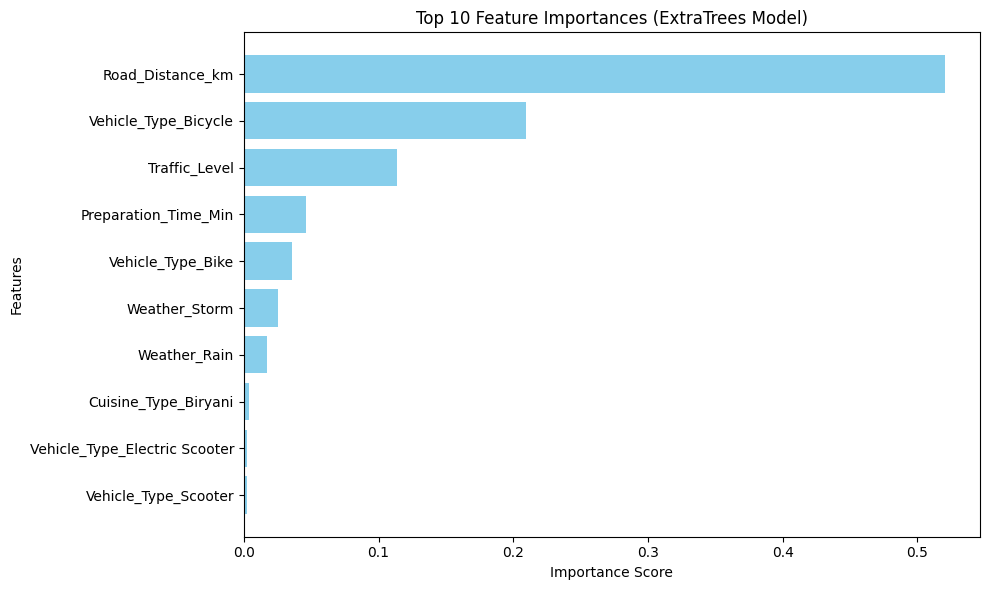

,Feature,Importance
0,Road_Distance_km,0.520368
1,Vehicle_Type_Bicycle,0.209099
2,Traffic_Level,0.113606
3,Preparation_Time_Min,0.045849
4,Vehicle_Type_Bike,0.036047
5,Weather_Storm,0.025555
6,Weather_Rain,0.016965
7,Cuisine_Type_Biryani,0.004141
8,Vehicle_Type_Electric Scooter,0.002458
9,Vehicle_Type_Scooter,0.002394


In [ ]:
# feature importance
# 1. Extract feature names from OneHotEncoder inside preprocessor
ohe_feature_names = best_pipeline.named_steps['preprocessor'] \
    .named_transformers_['nominal'] \
    .named_steps['scalar'] \
    .get_feature_names_out(nominal_col)

# 2. Combine all feature names in exact order of preprocessor transformers
all_feature_names = list(num_cols) + list(ohe_feature_names) + list(ordinal_col)

# 3. Get feature importances from tuned ExtraTrees model
importances = best_pipeline.named_steps['model'].feature_importances_

# 4. Create DataFrame and plot top 10 features
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'].head(10), feat_imp_df['Importance'].head(10), color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Feature Importances (ExtraTrees Model)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 5. Display top features table
feat_imp_df.head(10).reset_index(drop=True)


In [ ]:
import joblib

# Save the trained best pipeline to Google Drive
model_filename = "/content/drive/MyDrive/extra_trees_pipeline.joblib"
joblib.dump(best_pipeline, model_filename)

print(f"Model saved successfully to {model_filename}")

Model saved successfully to /content/drive/MyDrive/extra_trees_pipeline.joblib
